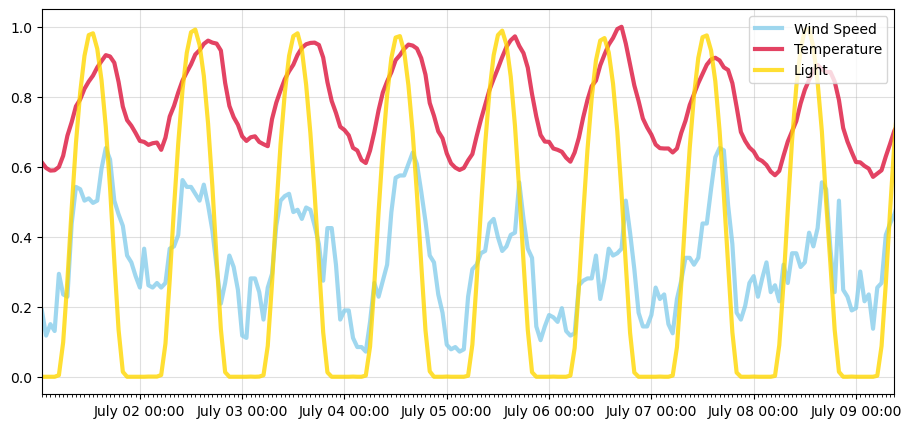

In [45]:

'''
'Stn Id', 'Stn Name', 'CIMIS Region', 'Date', 'Hour (PST)', 'Jul',
       'ETo (in)', 'qc', 'Precip (in)', 'qc.1', 'Sol Rad (Ly/day)', 'qc.2',
       'Vap Pres (mBars)', 'qc.3', 'Air Temp (F)', 'qc.4', 'Rel Hum (%)',
       'qc.5', 'Dew Point (F)', 'qc.6', 'Wind Speed (mph)', 'qc.7',
       'Wind Dir (0-360)', 'qc.8', 'Soil Temp (F)', 'qc.9'
'''
import pandas as pd 

data = pd.read_csv("Holt_CIMIS_data.csv")
times = []
for d,h in zip(data['Date'],data['Hour (PST)']): 
    if "24" in str(h):
        t = pd.to_datetime("%s 2359" % d , format="%m/%d/%Y %H%M") + pd.Timedelta(minutes=1)
    else: 
        
        t = pd.to_datetime("%s %s" % (d,h), format="%m/%d/%Y %H00") 
    times.append(t)
data.index = times 
# data.sort_index(ascending=True)
wind = data["Wind Speed (mph)"]
temp = data["Air Temp (F)"]


# https://www.wcc.nrcs.usda.gov/ftpref/wntsc/H&H/GEM/SolarRadConversion.pdf
data["Sol Rad (Watts/m2)"] = data["Sol Rad (Ly/day)"] *  0.484583 #  1 Langley/day = 0.484583 Watt/m2 
data["Sol Rad (PAR)"] = data["Sol Rad (Watts/m2)"] * 2.02
light = data["Sol Rad (PAR)"] 

# 1 ly/min = 697.3 W/m2


import matplotlib.dates as mdates
# print(time)
# print(times)
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(11,5))
ax = plt.gca()
ax.plot(wind/max(wind), color="skyblue", linewidth= 3, alpha = 0.8, label="Wind Speed")
ax.plot(temp/max(temp),color="crimson", linewidth= 3, alpha = 0.8, label = "Temperature")
ax.plot(light/max(light),color="gold", linewidth= 3, alpha = 0.8, label="Light")
ax.set_xlim(times[0], times[200])
# Format datetime axis
ax.xaxis.set_minor_locator(mdates.HourLocator())
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.grid(alpha=0.4)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %d %H:00'))
plt.show()

# Test


In [46]:
data_out = 0 
data_out = data[["Sol Rad (PAR)"]] 
data_out["Air Temp (C)"] = (data["Air Temp (F)"] - 32) * 5/9
data_out["Wind Speed (m/s)"] = data["Wind Speed (mph)"] * 0.44704

data_out = data_out.dropna()

# Downsample to time step
dt = 10 # seconds
data_out = data_out.resample("10s").interpolate("linear") 
print(data_out )

data_out.to_csv("Holt_CIMIS_data_processed_August2024_10s.csv")

/tmp/ipykernel_578845/2255943195.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out["Air Temp (C)"] = (data["Air Temp (F)"] - 32) * 5/9
/tmp/ipykernel_578845/2255943195.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out["Wind Speed (m/s)"] = data["Wind Speed (mph)"] * 0.44704


                     Sol Rad (PAR)  Air Temp (C)  Wind Speed (m/s)
2024-07-01 01:00:00       0.000000     18.333333          1.296416
2024-07-01 01:00:10       0.000000     18.330710          1.295050
2024-07-01 01:00:20       0.000000     18.328086          1.293684
2024-07-01 01:00:30       0.000000     18.325463          1.292318
2024-07-01 01:00:40       0.000000     18.322840          1.290952
...                            ...           ...               ...
2024-08-30 13:59:20    1654.410836     29.824691          3.978656
2024-08-30 13:59:30    1654.130774     29.826852          3.978656
2024-08-30 13:59:40    1653.850712     29.829012          3.978656
2024-08-30 13:59:50    1653.570650     29.831173          3.978656
2024-08-30 14:00:00    1653.290588     29.833333          3.978656

[523081 rows x 3 columns]
